In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open('similarity_metrics.pickle', 'rb') as f:
    metrics_dict = pickle.load(f)

In [3]:
metrics_dict.keys()

dict_keys(['average_difference_top@20'])

In [4]:
list(metrics_dict['average_difference_top@20'].items())[:3]

[(frozenset({'coles_gnn__pretrained_unfreeze_after_10_epoches__wl-0.5_gnn-GraphSAGE_res-True_wd-0.01__pretrain_epoches_75__epoches_40_embeddings',
             'mles_model_small_batch_2_embeddings__40_epoches'}),
  0.9933166666665583),
 (frozenset({'coles_gnn__g_0_5__no_orig_emb__sample_2__embeddings__graph_sage',
             'mles_model_small_batch_2_embeddings__40_epoches'}),
  0.9932326666665559),
 (frozenset({'check_coles_only__pretrained_epoches_9__coles_gnn_weighted__w_pred__no_gnn_GraphSAGE__no_orig__alpha_0.5__gamma_0.5____lp_criterion_MSELoss__40_epoches__epoches_after_ckpt_30__try_1_embeddings',
             'mles_model_small_batch_2_embeddings__40_epoches'}),
  0.9932719999998916)]

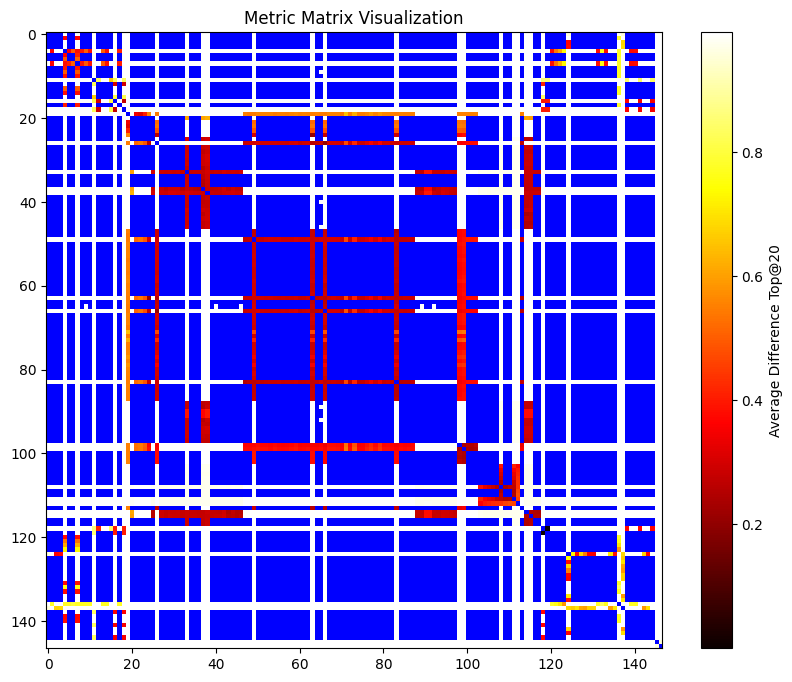

In [5]:
# Extract all unique experiment names
experiment_names = set()
for pair in metrics_dict['average_difference_top@20'].keys():
    experiment_names.update(pair)
experiment_names = sorted(experiment_names)  # Sort for consistent ordering
n_experiments = len(experiment_names)

# Create a matrix
matrix = np.zeros((n_experiments, n_experiments))

for i, exp1 in enumerate(experiment_names):
    for j, exp2 in enumerate(experiment_names):
        value = metrics_dict['average_difference_top@20'].get(frozenset([exp1, exp2]), np.nan)
        matrix[i, j] = value

# Visualize the matrix with NaN values in blue
cmap = plt.cm.hot
cmap.set_bad(color='blue')  # Set the color for NaN values

plt.figure(figsize=(10, 8))
plt.imshow(matrix, cmap=cmap, interpolation='nearest')
plt.colorbar(label='Average Difference Top@20')
# plt.xticks(ticks=np.arange(n_experiments), labels=experiment_names, rotation=90)
# plt.yticks(ticks=np.arange(n_experiments), labels=experiment_names)
plt.title('Metric Matrix Visualization')
plt.show()


In [6]:
# For each experiment name get list of tuples (exp_name, metric) with all exp_name from the dict, sorted by metric
from collections import defaultdict

experiment_name_to_closest_experimnts = defaultdict(list)
for experiment_name in experiment_names:
    for neighbour_experiment_name in experiment_names:
        key = frozenset({experiment_name, neighbour_experiment_name})
        if key not in metrics_dict['average_difference_top@20']:
            continue
        metric_value = metrics_dict['average_difference_top@20'][key]
        experiment_name_to_closest_experimnts[experiment_name].append((neighbour_experiment_name, metric_value))

    experiment_name_to_closest_experimnts[experiment_name].sort(key=lambda x: x[1])

In [ ]:
experiment_name_to_closest_experimnts

In [ ]:
for k,v in experiment_name_to_closest_experimnts.items():
    if v[0][1] > 0.9: 
        continue
    print(k)
    print(v)
    print("---")